Reference root width: 27.9 mm
Scaled root width for M=2 kg, L=100 mm: 12.5 mm
Auto-calculated: R_root = 97.7 mm, R_tip = 20.0 mm
Computed final tip radius: 21.0 mm (target: 20.0 mm)
GAS Blade Design Results
Load: 2 kg
Length: 100 mm
Material: Ti-6Al-4V Titanium
Root width: 12.5 mm
Tip width: 1.4 mm
Recommended thickness: 0.73 mm
Force per blade: 3.3 N
Vertical rise: 62.3 mm
Root radius: 97.7 mm
Tip radius: 21.0 mm


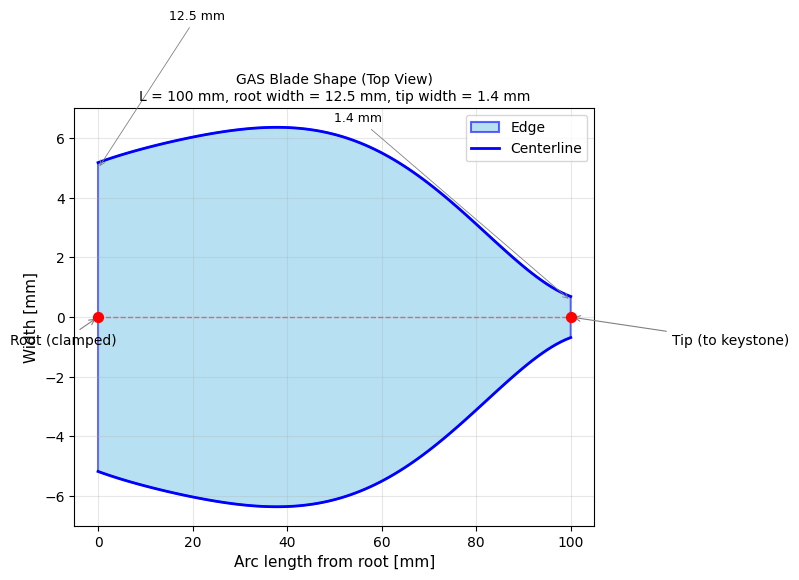

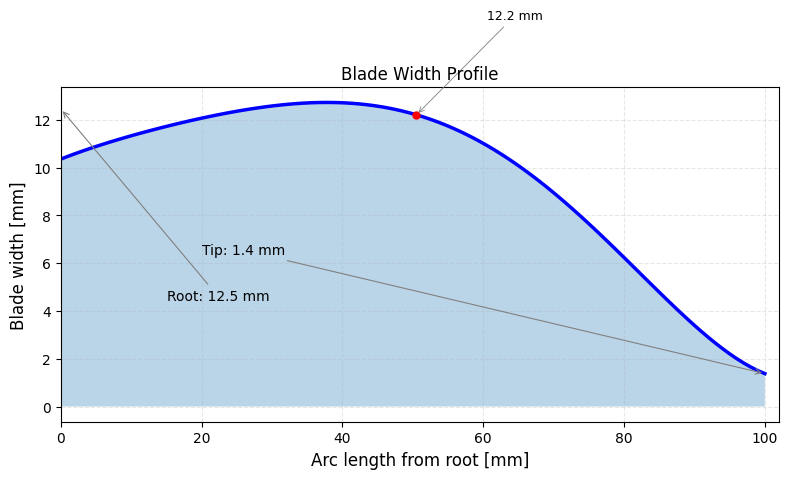

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.



Figure 3 bounds:
  x: [-29.0, 131.9] mm
  y: [-30.0, 93.2] mm
  Aspect ratio: 1.31 → figure size: 10×8


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


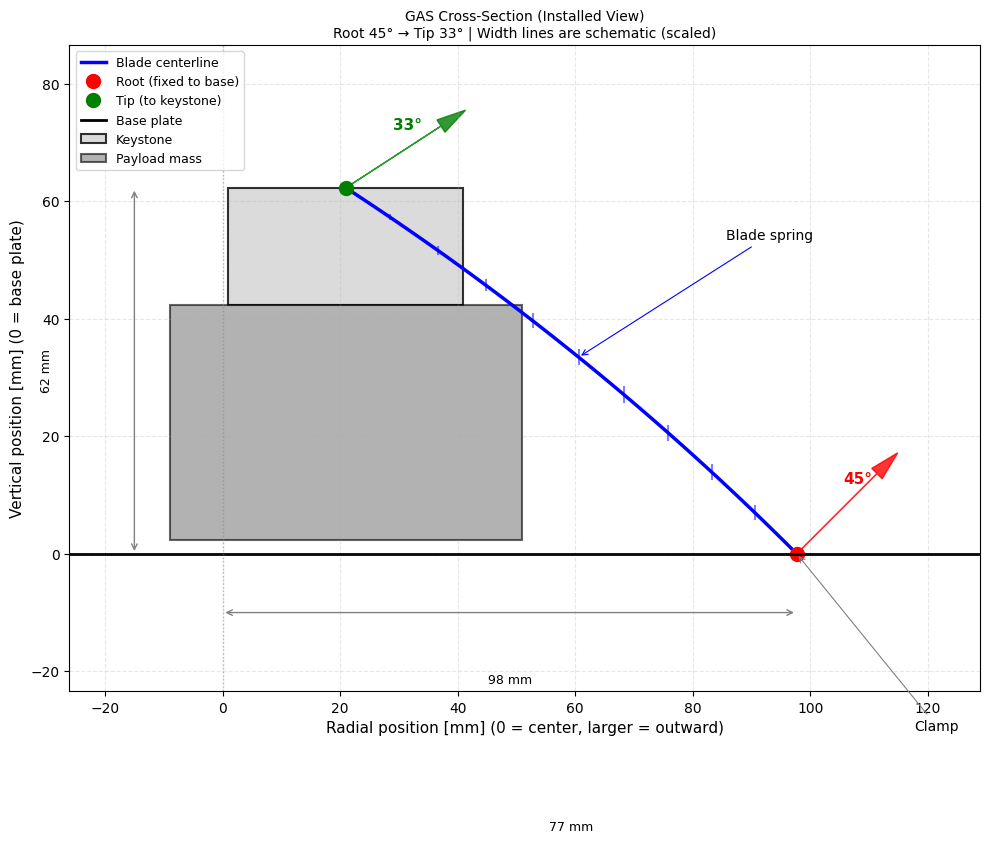


✓ Shape coordinates saved to 'blade_shape.csv'


In [7]:
# GAS Blade Calculator - Three Plots for PPT
# Plot 1: Flattened blade top view (symmetric shape)
# Plot 2: Width vs arc length curve
# Plot 3: Installed 2D cross-section (radial plane) with auto-scaling

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import csv

# ==========================================
# User input - change these values
# ==========================================
M = 2           # Load mass [kg]
L = 100          # Blade arc length [mm]
material = "Ti"  # "Steel" or "Ti"

# Optional: manually override root radius (if you have a fixed mounting geometry)
# Set to None to auto-calculate from L and angles
MANUAL_ROOT_RADIUS = None   # e.g., 80.0 [mm] or None for auto

# ==========================================
# Material properties
# ==========================================
if material == "Steel":
    E = 196                       # Young's modulus [GPa]
    yield_strength = 1500         # Yield strength [MPa]
    material_name = "60Si2CrVA Spring Steel"
else:  # Titanium
    E = 114                       # Young's modulus [GPa]
    yield_strength = 1000         # Yield strength [MPa]
    material_name = "Ti-6Al-4V Titanium"

# Fixed parameters
g = 9.81
N = 6                     # Number of blades

# ==========================================
# Root width scaling (based on reference design)
# Reference: M_ref = 8 kg, L_ref = 133.64 mm, w_root_ref = 27.9 mm
# Scaling law: w_root ∝ (M / M_ref) * (L_ref / L)^2
# ==========================================
M_ref = 8.0
L_ref = 133.64
w_root_ref = 27.9
w_root_scaled = w_root_ref * (M / M_ref) * (L_ref / L)**2
print(f"Reference root width: {w_root_ref:.1f} mm")
print(f"Scaled root width for M={M} kg, L={L} mm: {w_root_scaled:.1f} mm")

w_root = w_root_scaled   # Use scaled root width

safety_factor = 2
allowable_stress = yield_strength / safety_factor   # [MPa]

# Forces
total_weight = M * g
force_per_blade = total_weight / N

# Minimum required thickness (cantilever bending)
L_m = L / 1000
w_root_m = w_root / 1000
sigma_Pa = allowable_stress * 1e6
d_min_m = ((6 * force_per_blade * L_m) / (w_root_m * sigma_Pa)) ** 0.5
d_min_mm = d_min_m * 1000
d_rec_mm = d_min_mm * 1.3          # 30% safety margin

# ==========================================
# Blade shape (five-order polynomial, zero-stiffness profile)
# Coefficients from Cella et al. (2005)
# ==========================================
c0 = 0.8317
c1 = 0.9328
c2 = -1.9631
c3 = 5.8534
c4 = -12.22
c5 = 6.6757

def width_mm_poly(xi):
    """Return blade width [mm] at normalized arc length xi = s/L."""
    poly_val = c0 + c1*xi + c2*xi**2 + c3*xi**3 + c4*xi**4 + c5*xi**5
    return w_root * poly_val

n_points = 100
xi = np.linspace(0, 1, n_points)
width_mm = np.array([width_mm_poly(x) for x in xi])
arc_mm = xi * L

# ==========================================
# Installation geometry (radial plane)
# Root angle 45°, tip angle 33° (both above horizontal)
# ==========================================
# Compute geometric parameters consistent with arc length L and angles
theta_root_deg = 45.0
theta_tip_deg = 33.0
theta_mean_deg = (theta_root_deg + theta_tip_deg) / 2.0
theta_mean_rad = np.radians(theta_mean_deg)

# Horizontal projection for a blade with linearly varying angle
horizontal_proj = L * np.cos(theta_mean_rad)

if MANUAL_ROOT_RADIUS is not None:
    R_root = MANUAL_ROOT_RADIUS
    R_tip = R_root - horizontal_proj
    print(f"Using manual R_root = {R_root:.1f} mm, computed R_tip = {R_tip:.1f} mm")
else:
    R_tip = 20.0   # typical keystone radius
    R_root = R_tip + horizontal_proj
    print(f"Auto-calculated: R_root = {R_root:.1f} mm, R_tip = {R_tip:.1f} mm")

# Linear angle interpolation along arc length
theta_deg = theta_root_deg * (1 - xi) + theta_tip_deg * xi
theta_rad = np.radians(theta_deg)

# Integrate to obtain radial and vertical coordinates
r = np.zeros(n_points)
z = np.zeros(n_points)
r[0] = R_root
z[0] = 0.0

ds = L / n_points

for i in range(1, n_points):
    dr = np.cos(theta_rad[i-1]) * ds
    dz = np.sin(theta_rad[i-1]) * ds
    r[i] = r[i-1] - dr       # moving inward (decreasing radius)
    z[i] = z[i-1] + dz       # upward positive

final_tip_radius = r[-1]
print(f"Computed final tip radius: {final_tip_radius:.1f} mm (target: {R_tip:.1f} mm)")
if abs(final_tip_radius - R_tip) > 5:
    print(f"Warning: Tip radius deviation >5 mm. Consider adjusting MANUAL_ROOT_RADIUS.")

# Keystone dimensions (for visualisation)
keystone_width = 40   # width of keystone [mm]
keystone_height = 20  # height of keystone [mm]
keystone_x_center = final_tip_radius
keystone_y_top = z[-1]
keystone_y_bottom = z[-1] - keystone_height

# Mass block dimensions (for visualisation)
mass_width = 60       # width of mass block [mm]
mass_height = 40      # height of mass block [mm]
mass_x_center = final_tip_radius
mass_y_top = keystone_y_bottom
mass_y_bottom = keystone_y_bottom - mass_height

# ==========================================
# Print design results
# ==========================================
print("=" * 55)
print("GAS Blade Design Results")
print("=" * 55)
print(f"Load: {M} kg")
print(f"Length: {L} mm")
print(f"Material: {material_name}")
print(f"Root width: {w_root:.1f} mm")
print(f"Tip width: {width_mm[-1]:.1f} mm")
print(f"Recommended thickness: {d_rec_mm:.2f} mm")
print(f"Force per blade: {force_per_blade:.1f} N")
print(f"Vertical rise: {z[-1]:.1f} mm")
print(f"Root radius: {R_root:.1f} mm")
print(f"Tip radius: {final_tip_radius:.1f} mm")
print("=" * 55)

# ==========================================
# FIGURE 1: Flattened blade top view (adaptive)
# ==========================================
max_width = np.max(width_mm)
aspect_ratio = L / max_width
if aspect_ratio > 15:
    fig_w, fig_h = 10, 5
else:
    fig_w, fig_h = 8, 6

fig1, ax1 = plt.subplots(figsize=(fig_w, fig_h))

x_full = np.concatenate([arc_mm, arc_mm[::-1]])
y_full = np.concatenate([width_mm/2, -width_mm[::-1]/2])

ax1.fill(x_full, y_full, 'skyblue', edgecolor='blue', linewidth=1.5, alpha=0.6)
ax1.plot(arc_mm, width_mm/2, 'b-', linewidth=2)
ax1.plot(arc_mm, -width_mm/2, 'b-', linewidth=2)
ax1.plot([0, L], [0, 0], 'r--', linewidth=1, alpha=0.5)

ax1.scatter([0, L], [0, 0], c='red', s=50, zorder=5)

ax1.annotate('Root (clamped)', xy=(0, 0), xytext=(-25, -20),
             textcoords='offset points', fontsize=10, ha='center',
             arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))
ax1.annotate('Tip (to keystone)', xy=(L, 0), xytext=(L+15, -20),
             textcoords='offset points', fontsize=10, ha='center',
             arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))
ax1.annotate(f'{w_root:.1f} mm', xy=(0, w_root/2.5), xytext=(15, w_root/2.5+5), fontsize=9,
             arrowprops=dict(arrowstyle='->', color='gray', lw=0.6))
ax1.annotate(f'{width_mm[-1]:.1f} mm', xy=(L, width_mm[-1]/2.5),
             xytext=(L-50, width_mm[-1]/2.5+6), fontsize=9,
             arrowprops=dict(arrowstyle='->', color='gray', lw=0.6))

ax1.set_xlabel('Arc length from root [mm]', fontsize=11)
ax1.set_ylabel('Width [mm]', fontsize=11)
ax1.set_title(f'GAS Blade Shape (Top View)\nL = {L} mm, root width = {w_root:.1f} mm, tip width = {width_mm[-1]:.1f} mm', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.legend(['Edge', 'Centerline'], loc='upper right')
plt.tight_layout()
plt.show()

# ==========================================
# FIGURE 2: Width vs arc length
# ==========================================
fig2, ax2 = plt.subplots(figsize=(8, 5))

ax2.plot(arc_mm, width_mm, 'b-', linewidth=2.5)
ax2.fill_between(arc_mm, 0, width_mm, alpha=0.3)

ax2.set_xlabel('Arc length from root [mm]', fontsize=12)
ax2.set_ylabel('Blade width [mm]', fontsize=12)
ax2.set_title('Blade Width Profile', fontsize=12)
ax2.grid(True, alpha=0.3, linestyle='--')

ax2.annotate(f'Root: {w_root:.1f} mm', xy=(0, w_root), xytext=(15, w_root-8),
             fontsize=10, arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))
ax2.annotate(f'Tip: {width_mm[-1]:.1f} mm', xy=(L, width_mm[-1]),
             xytext=(L-80, width_mm[-1]+5), fontsize=10,
             arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

mid_idx = len(arc_mm)//2
ax2.plot(arc_mm[mid_idx], width_mm[mid_idx], 'ro', markersize=5)
ax2.annotate(f'{width_mm[mid_idx]:.1f} mm', xy=(arc_mm[mid_idx], width_mm[mid_idx]),
             xytext=(arc_mm[mid_idx]+10, width_mm[mid_idx]+4), fontsize=9,
             arrowprops=dict(arrowstyle='->', color='gray', lw=0.6))

ax2.set_xlim(0, L * 1.02)
plt.tight_layout()
plt.show()

# ==========================================
# FIGURE 3: Installed cross-section (FULLY ADAPTIVE - GUARANTEED COMPLETE)
# ==========================================
# Calculate ALL x and y coordinates from ALL elements
all_x = []
all_y = []

# Add blade points
all_x.extend(r)
all_y.extend(z)

# Add keystone corners
all_x.extend([keystone_x_center - keystone_width/2, keystone_x_center + keystone_width/2])
all_y.extend([keystone_y_top, keystone_y_bottom])

# Add mass block corners
all_x.extend([mass_x_center - mass_width/2, mass_x_center + mass_width/2])
all_y.extend([mass_y_top, mass_y_bottom])

# Add base plate endpoints (from 0 to R_root)
all_x.extend([0, R_root])
all_y.extend([0, 0])

# Add centerline reference (r=0)
all_x.append(0)
all_y.append(0)

# Add arrow tip positions (to ensure arrows are within bounds)
# Root arrow tip
root_arrow_tip_x = r[0] + 20 * np.cos(np.radians(45))
root_arrow_tip_y = z[0] + 20 * np.sin(np.radians(45))
all_x.append(root_arrow_tip_x)
all_y.append(root_arrow_tip_y)

# Tip arrow tip
tip_arrow_tip_x = r[-1] + 20 * np.cos(np.radians(33))
tip_arrow_tip_y = z[-1] + 20 * np.sin(np.radians(33))
all_x.append(tip_arrow_tip_x)
all_y.append(tip_arrow_tip_y)

# Compute bounds with generous margins
x_min = min(all_x) - 20
x_max = max(all_x) + 20
y_min = min(all_y) - 30
y_max = max(all_y) + 20

print(f"\nFigure 3 bounds:")
print(f"  x: [{x_min:.1f}, {x_max:.1f}] mm")
print(f"  y: [{y_min:.1f}, {y_max:.1f}] mm")

x_range = x_max - x_min
y_range = y_max - y_min

# Choose figure size based on aspect ratio of the geometry
aspect_ratio_geom = x_range / y_range
if aspect_ratio_geom > 1.5:
    fig_width = 12
    fig_height = 8
elif aspect_ratio_geom < 0.67:
    fig_width = 8
    fig_height = 12
else:
    fig_width = 10
    fig_height = 8

print(f"  Aspect ratio: {aspect_ratio_geom:.2f} → figure size: {fig_width}×{fig_height}")

fig3, ax3 = plt.subplots(figsize=(fig_width, fig_height))

# Blade centerline
ax3.plot(r, z, 'b-', linewidth=2.5, label='Blade centerline')

# Width indication (vertical bars at sampled points)
# Note: Width lines are scaled down by factor 5 for visual clarity
width_at_points = width_mm[::len(width_mm)//10]
r_at_points = r[::len(r)//10]
z_at_points = z[::len(z)//10]
for i in range(len(r_at_points)):
    half_w = width_at_points[i] / 2
    ax3.plot([r_at_points[i], r_at_points[i]],
             [z_at_points[i] - half_w/5, z_at_points[i] + half_w/5],
             'b-', linewidth=1.5, alpha=0.5)

# Root angle 45° arrow
root_tangent_len = min(25, x_range * 0.12)
root_angle_rad = np.radians(45)
ax3.arrow(r[0], z[0], root_tangent_len * np.cos(root_angle_rad),
          root_tangent_len * np.sin(root_angle_rad),
          head_width=2.5, head_length=5, fc='red', ec='red', alpha=0.8)
ax3.text(r[0] + 8, z[0] + 12, '45°', fontsize=11, color='red', fontweight='bold')

# Tip angle 33° arrow
tip_angle_rad = np.radians(33)
ax3.arrow(r[-1], z[-1], root_tangent_len * np.cos(tip_angle_rad),
          root_tangent_len * np.sin(tip_angle_rad),
          head_width=2.5, head_length=5, fc='green', ec='green', alpha=0.8)
ax3.text(r[-1] + 8, z[-1] + 10, '33°', fontsize=11, color='green', fontweight='bold')

# Root and tip markers
ax3.plot(r[0], z[0], 'ro', markersize=10, label='Root (fixed to base)')
ax3.plot(r[-1], z[-1], 'go', markersize=10, label='Tip (to keystone)')

# Base plate (horizontal line at y=0)
ax3.axhline(y=0, color='k', linestyle='-', linewidth=2, label='Base plate')

# Keystone (light gray rectangle)
keystone_rect = Rectangle((keystone_x_center - keystone_width/2, keystone_y_bottom),
                          keystone_width, keystone_height,
                          facecolor='lightgray', edgecolor='black', linewidth=1.5, alpha=0.8, label='Keystone')
ax3.add_patch(keystone_rect)

# Mass block (dark gray rectangle)
mass_rect = Rectangle((mass_x_center - mass_width/2, mass_y_bottom),
                      mass_width, mass_height,
                      facecolor='gray', edgecolor='black', linewidth=1.5, alpha=0.6, label='Payload mass')
ax3.add_patch(mass_rect)

# Annotations
ax3.annotate('Clamp', xy=(r[0], z[0]), xytext=(r[0] + 20, z[0] - 30),
             arrowprops=dict(arrowstyle='->', color='gray', lw=0.8), fontsize=10)
ax3.annotate('Blade spring', xy=(r[len(r)//2], z[len(z)//2]), 
             xytext=(r[len(r)//2] + 25, z[len(z)//2] + 20),
             arrowprops=dict(arrowstyle='->', color='blue', lw=0.8), fontsize=10)

# Dimension lines - radial
ax3.annotate('', xy=(0, -10), xytext=(R_root, -10),
             arrowprops=dict(arrowstyle='<->', color='gray', lw=1.0))
ax3.text(R_root/2, -22, f'{R_root:.0f} mm', fontsize=9, ha='center')
ax3.annotate('', xy=(final_tip_radius, -35), xytext=(R_root, -35),
             arrowprops=dict(arrowstyle='<->', color='gray', lw=1.0))
ax3.text((R_root + final_tip_radius)/2, -47, f'{R_root - final_tip_radius:.0f} mm', fontsize=9, ha='center')

# Dimension line - vertical
ax3.annotate('', xy=(-15, 0), xytext=(-15, z[-1]),
             arrowprops=dict(arrowstyle='<->', color='gray', lw=1.0))
ax3.text(-30, z[-1]/2, f'{z[-1]:.0f} mm', fontsize=9, ha='center', va='center', rotation=90)

# Final axis settings
ax3.set_xlabel('Radial position [mm] (0 = center, larger = outward)', fontsize=11)
ax3.set_ylabel('Vertical position [mm] (0 = base plate)', fontsize=11)
ax3.set_title('GAS Cross-Section (Installed View)\nRoot 45° → Tip 33° | Width lines are schematic (scaled)', fontsize=10)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.legend(loc='upper left', fontsize=9)
ax3.axis('equal')
ax3.set_xlim(x_min, x_max)
ax3.set_ylim(y_min, y_max)

# Add a faint vertical line at r=0 (centerline)
ax3.axvline(x=0, color='gray', linestyle=':', linewidth=1, alpha=0.5)

# Add a faint horizontal line at base plate reference
ax3.axhline(y=0, color='gray', linestyle=':', linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# Save coordinates for CAD
# ==========================================
with open("blade_shape.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["arc_mm", "half_width_mm", "full_width_mm"])
    for arc, wd in zip(arc_mm, width_mm):
        writer.writerow([f"{arc:.3f}", f"{wd/2:.3f}", f"{wd:.3f}"])

print("\n✓ Shape coordinates saved to 'blade_shape.csv'")